# 05 — Advanced Analytics

Risk, performance, and investor-behavior analytics on top of the cleaned,
ETL-processed datasets. Also includes two bonus sections: Monte Carlo NAV
projection (B3) and Markowitz Efficient Frontier optimisation (B4).

**⚠️ Data note:** `data/raw/08_investor_transactions.csv` was not part of
the source export. Tasks 3 and 4 below (investor cohorts, SIP continuity)
run on a **synthetic, seeded stand-in** generated by
`scripts/generate_synthetic_transactions.py`. Every result derived from
it is labeled *(synthetic)*. Tasks 1, 2, 5, 6 and the bonus sections use
the project's real, cleaned data throughout.


In [1]:
import sys
sys.path.append("../scripts")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import analytics_lib as al

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.dpi"] = 110
plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(42)


## 0. Load data

In [2]:
fund_master = al.load_fund_master()
scheme_perf = al.load_scheme_performance()
nav = al.load_nav_history()
holdings = al.load_portfolio_holdings()
txns = al.load_transactions()

returns = al.compute_daily_returns(nav)

print(f"Funds (schemes):        {fund_master['amfi_code'].nunique()}")
print(f"NAV history rows:       {len(nav):,}   date range {nav['date'].min().date()} -> {nav['date'].max().date()}")
print(f"Daily return matrix:    {returns.shape[0]} trading days x {returns.shape[1]} schemes")
print(f"Portfolio holdings:     {len(holdings):,} rows, {holdings['amfi_code'].nunique()} equity funds")
print(f"Transactions (SYNTH.):  {len(txns):,} rows, {txns['investor_id'].nunique():,} investors")


Funds (schemes):        40
NAV history rows:       46,000   date range 2022-01-03 -> 2026-05-29
Daily return matrix:    1149 trading days x 40 schemes
Portfolio holdings:     322 rows, 34 equity funds
Transactions (SYNTH.):  32,994 rows, 1,897 investors


## 1. Historical VaR & CVaR (95%) — all 40 schemes

- **VaR(95%)** = 5th percentile of the daily-return distribution.
- **CVaR(95%)** = mean of returns at/below the VaR threshold (Expected Shortfall).

In [3]:
var_cvar = al.compute_var_cvar(returns, confidence=0.95)
var_cvar = var_cvar.merge(
    fund_master[["amfi_code", "scheme_name", "category", "risk_category"]],
    on="amfi_code", how="left"
)
var_cvar = var_cvar[["amfi_code", "scheme_name", "category", "risk_category",
                      "n_obs", "mean_daily_return_pct", "std_daily_return_pct",
                      "VaR_95_pct", "CVaR_95_pct"]]
var_cvar.to_csv("../reports/var_cvar_report.csv", index=False)
print(f"Saved reports/var_cvar_report.csv  ({len(var_cvar)} schemes)")
var_cvar.nsmallest(5, "VaR_95_pct")[["scheme_name", "category", "VaR_95_pct", "CVaR_95_pct"]]


Saved reports/var_cvar_report.csv  (40 schemes)


,scheme_name,category,VaR_95_pct,CVaR_95_pct
0,SBI Small Cap Fund - Direct Plan - Growth,Equity,-2.69,-3.24
1,Axis Small Cap Fund - Regular - Growth,Equity,-2.62,-3.17
2,ABSL Small Cap Fund - Regular - Growth,Equity,-2.60,-3.25
3,Nippon India Small Cap Fund - Regular - Growth,Equity,-2.54,-3.23
4,SBI Small Cap Fund - Regular Plan - Growth,Equity,-2.45,-3.06


## 2. Rolling 90-day Sharpe ratio — 5 key funds (top-5 by AUM)

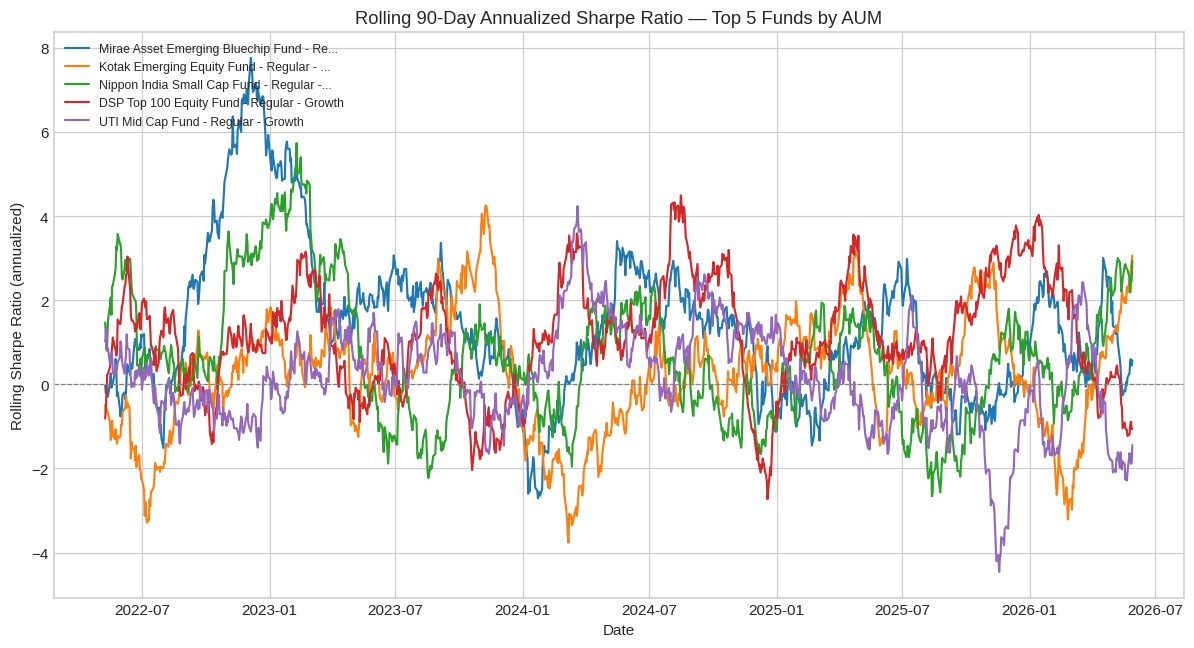

In [4]:
key_funds = scheme_perf.sort_values("aum_crore", ascending=False).head(5)[
    ["amfi_code", "scheme_name", "category", "aum_crore"]]
rolling_sharpe = al.compute_rolling_sharpe(returns, window=90)
rolling_sharpe_key = rolling_sharpe[key_funds["amfi_code"].tolist()]

fig, ax = plt.subplots(figsize=(11, 6))
name_map = key_funds.set_index("amfi_code")["scheme_name"]
for c in rolling_sharpe_key.columns:
    label = name_map[c]
    ax.plot(rolling_sharpe_key.index, rolling_sharpe_key[c],
            label=label if len(label) <= 42 else label[:39] + "...", linewidth=1.4)
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("Rolling 90-Day Annualized Sharpe Ratio — Top 5 Funds by AUM")
ax.set_xlabel("Date"); ax.set_ylabel("Rolling Sharpe Ratio (annualized)")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig("../reports/charts/rolling_sharpe_chart.png", dpi=150)
plt.show()


## 3. Investor cohort analysis *(synthetic transaction data)*

Cohort = calendar year of an investor's first-ever transaction.

In [5]:
cohorts = al.compute_investor_cohorts(txns, fund_master)
cohorts


,cohort_year,n_investors,avg_sip_amount_inr,total_invested_inr,top_fund_preference,top_fund_amfi_code
0,2022,405,"2,369.57",33650979,ICICI Pru Bluechip Fund - Regular - Growth,120503
1,2023,443,"2,547.64",38570398,ICICI Pru Bluechip Fund - Regular - Growth,120503
2,2024,460,"2,288.67",32112412,ICICI Pru Bluechip Fund - Regular - Growth,120503
3,2025,415,"2,490.26",23200270,ICICI Pru Bluechip Fund - Regular - Growth,120503
4,2026,174,"2,388.49",7113258,ICICI Pru Bluechip Fund - Regular - Growth,120503


/tmp/ipykernel_612/4193147392.py:6: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


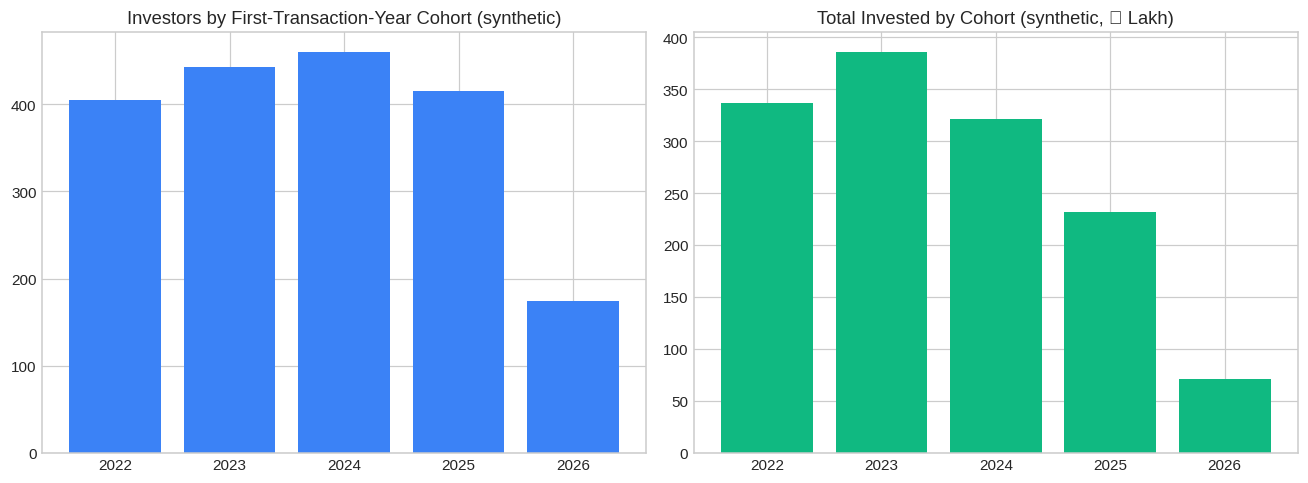

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(cohorts["cohort_year"].astype(str), cohorts["n_investors"], color="#3B82F6")
axes[0].set_title("Investors by First-Transaction-Year Cohort (synthetic)")
axes[1].bar(cohorts["cohort_year"].astype(str), cohorts["total_invested_inr"] / 1e5, color="#10B981")
axes[1].set_title("Total Invested by Cohort (synthetic, ₹ Lakh)")
fig.tight_layout()
plt.show()


## 4. SIP continuity analysis *(synthetic transaction data)*

Investors with 6+ SIPs; average gap > 35 days flagged "at-risk".

In [7]:
sip_continuity = al.compute_sip_continuity(txns, min_sips=6, at_risk_gap_days=35)
n_total, n_at_risk = len(sip_continuity), int(sip_continuity["at_risk"].sum())
print(f"Eligible investors (6+ SIPs): {n_total:,}")
print(f"At-risk investors (avg gap > 35 days): {n_at_risk:,}  ({n_at_risk/n_total*100:.1f}%)")
sip_continuity.head(10)


Eligible investors (6+ SIPs): 1,549
At-risk investors (avg gap > 35 days): 610  (39.4%)


,investor_id,n_sip_transactions,avg_gap_days,max_gap_days,at_risk
0,INV100899,7,66.30,91,True
1,INV101612,6,62.60,98,True
2,INV100077,9,61.10,109,True
3,INV101419,18,60.80,99,True
4,INV101514,6,59.20,76,True
5,INV101889,14,57.00,109,True
6,INV101316,11,56.60,89,True
7,INV100825,9,56.10,73,True
8,INV100111,14,55.90,90,True
9,INV101735,6,55.80,85,True


## 5. Simple fund recommender

Top 3 funds by Sharpe ratio within a matching `risk_grade` bucket. Logic lives in
`scripts/recommender.py` so it also runs standalone from the command line.

In [8]:
from recommender import recommend_and_print
for appetite in ["Low", "Moderate", "High"]:
    recommend_and_print(appetite, scheme_perf)



  TOP 3 FUND RECOMMENDATIONS — Risk Appetite: Low
  (matching risk_grade: Low)
 Rank                                     Fund               Fund House Category Risk Grade  Sharpe  Sortino  3Y Return %  Std Dev % (Ann)  Expense %
    1 ICICI Pru Liquid Fund - Regular - Growth      ICICI Prudential MF   Liquid        Low    7.68    10.37         7.68             0.50       0.74
    2     Kotak Liquid Fund - Regular - Growth        Kotak Mahindra MF   Liquid        Low    6.18     9.70         6.18             0.50       0.60
    3      ABSL Liquid Fund - Regular - Growth Aditya Birla Sun Life MF   Liquid        Low    5.14     8.76         5.14             0.50       0.79


  TOP 3 FUND RECOMMENDATIONS — Risk Appetite: Moderate
  (matching risk_grade: Moderate, Moderately High)
 Rank                                          Fund          Fund House  Category Risk Grade  Sharpe  Sortino  3Y Return %  Std Dev % (Ann)  Expense %
    1     HDFC Top 100 Fund - Regular Plan - Growth    HDFC M

## 6. Sector HHI concentration — equity funds

HHI = Σ(sector weight_i²). <1,500 diversified, 1,500-2,500 moderately concentrated, >2,500 highly concentrated.

In [9]:
hhi = al.compute_sector_hhi(holdings, fund_master)
hhi.to_csv("../reports/sector_hhi_report.csv", index=False)
print(f"Saved reports/sector_hhi_report.csv ({len(hhi)} equity schemes)")
hhi.head(10)


Saved reports/sector_hhi_report.csv (34 equity schemes)


,amfi_code,HHI,concentration,scheme_name,category
0,119092,"2,967.70",Highly Concentrated,Axis Bluechip Fund - Regular - Growth,Equity
1,148569,"2,549.90",Highly Concentrated,Mirae Asset Tax Saver Fund - Regular - Growth,Equity
2,125498,"2,531.60",Highly Concentrated,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
3,102887,"2,513.80",Highly Concentrated,UTI Flexi Cap Fund - Regular - Growth,Equity
4,149323,"2,410.80",Moderately Concentrated,DSP Midcap Fund - Regular - Growth,Equity
5,120505,"2,387.00",Moderately Concentrated,ICICI Pru Midcap Fund - Regular - Growth,Equity
6,118635,"2,375.00",Moderately Concentrated,Nippon India ETF Nifty 50 BeES,Equity
7,119599,"2,323.60",Moderately Concentrated,SBI Small Cap Fund - Direct Plan - Growth,Equity
8,120506,"2,314.60",Moderately Concentrated,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
9,100033,"2,276.50",Moderately Concentrated,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity


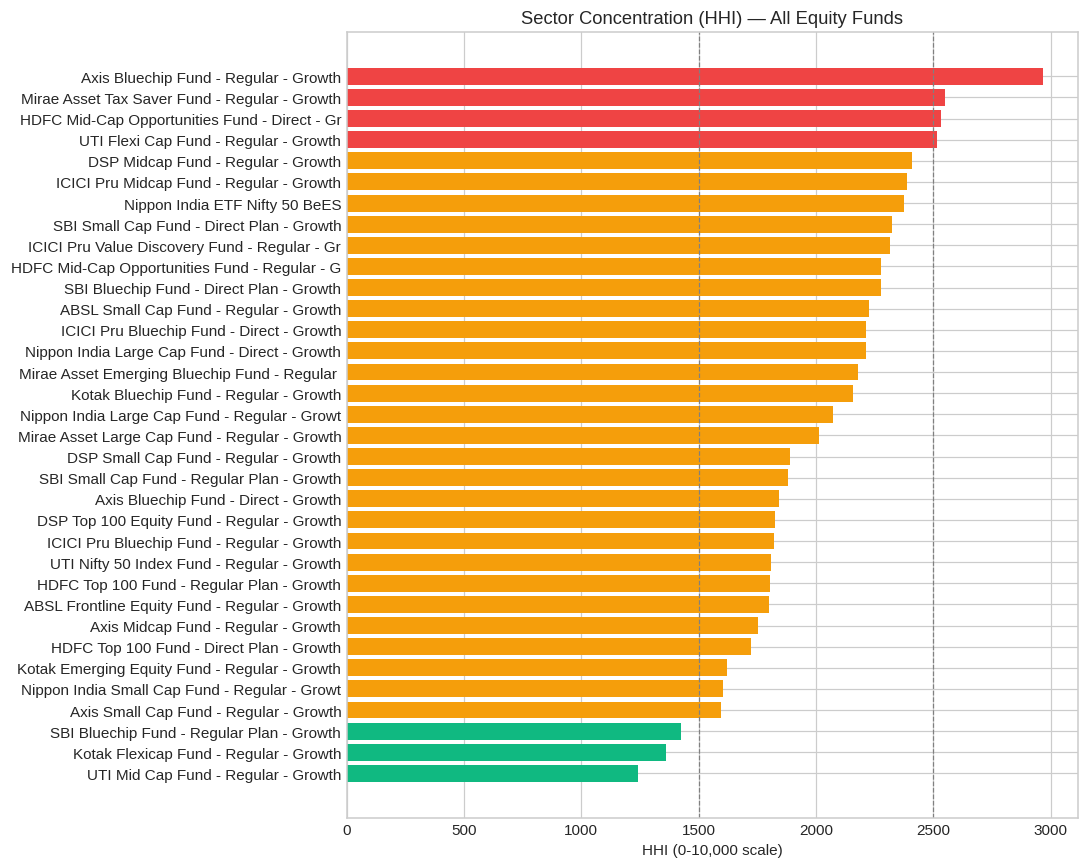

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
plot_df = hhi.sort_values("HHI")
colors = plot_df["concentration"].map({
    "Diversified": "#10B981", "Moderately Concentrated": "#F59E0B", "Highly Concentrated": "#EF4444"})
ax.barh(plot_df["scheme_name"].str.slice(0, 45), plot_df["HHI"], color=colors)
ax.axvline(1500, color="grey", linestyle="--", linewidth=0.8)
ax.axvline(2500, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("Sector Concentration (HHI) — All Equity Funds")
ax.set_xlabel("HHI (0-10,000 scale)")
fig.tight_layout()
plt.show()


## Bonus B3 — Monte Carlo NAV projection (5-year, with uncertainty bands)

For a chosen fund, simulate 5-year NAV paths using Geometric Brownian
Motion parameterized from its own historical daily return
mean/volatility: `NAV_t = NAV_0 * exp((mu - 0.5*sigma^2)*t + sigma*sqrt(t)*Z)`,
run 2,000 simulated paths, and plot the median path with 10th-90th
percentile uncertainty bands.

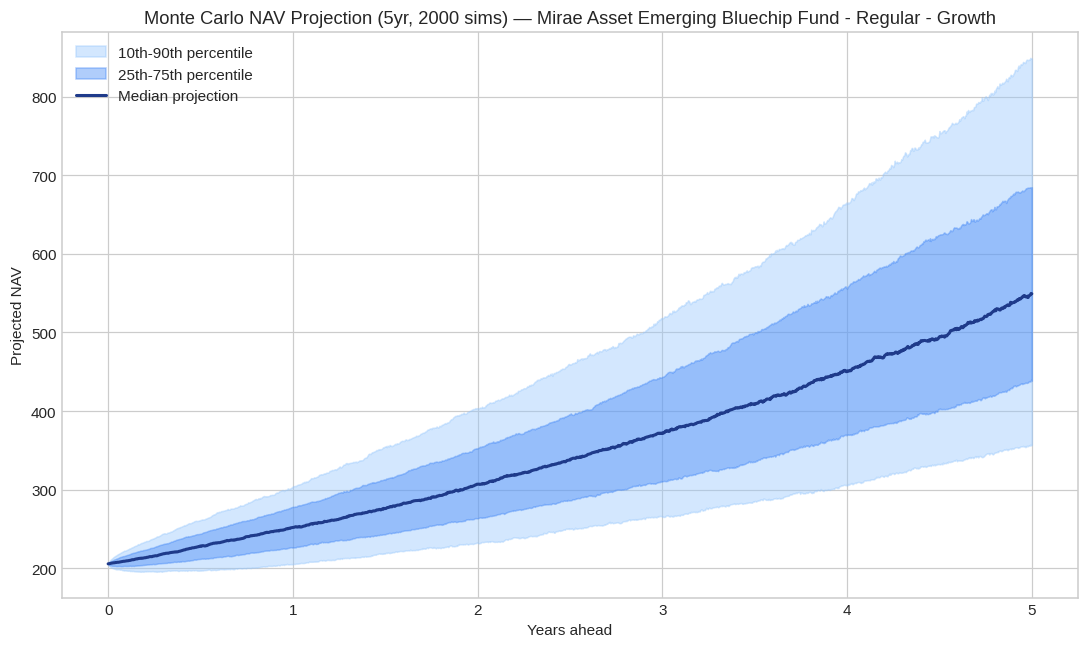

5-year projected NAV for Mirae Asset Emerging Bluechip Fund - Regular - Growth:
  Median: 549.31   10th pct: 357.02   90th pct: 848.82
  (Starting NAV: 205.45, implied median CAGR: 21.74%)


In [11]:
def monte_carlo_nav_projection(amfi_code, returns, nav, years=5, n_sims=2000, seed=42):
    rng = np.random.default_rng(seed)
    r = returns[amfi_code].dropna()
    mu, sigma = r.mean(), r.std()
    n_days = int(years * 252)
    nav0 = nav[nav["amfi_code"] == amfi_code]["nav"].iloc[-1]

    Z = rng.standard_normal((n_sims, n_days))
    daily_log_returns = (mu - 0.5 * sigma**2) + sigma * Z
    log_paths = np.cumsum(daily_log_returns, axis=1)
    paths = nav0 * np.exp(log_paths)
    paths = np.hstack([np.full((n_sims, 1), nav0), paths])
    return paths

target_code = key_funds.iloc[0]["amfi_code"]
target_name = key_funds.iloc[0]["scheme_name"]
paths = monte_carlo_nav_projection(target_code, returns, nav, years=5, n_sims=2000)

pctiles = np.percentile(paths, [10, 25, 50, 75, 90], axis=0)
days = np.arange(paths.shape[1])
years_axis = days / 252

fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(years_axis, pctiles[0], pctiles[4], color="#93C5FD", alpha=0.4, label="10th-90th percentile")
ax.fill_between(years_axis, pctiles[1], pctiles[3], color="#3B82F6", alpha=0.4, label="25th-75th percentile")
ax.plot(years_axis, pctiles[2], color="#1E3A8A", linewidth=2, label="Median projection")
ax.set_title(f"Monte Carlo NAV Projection (5yr, 2000 sims) — {target_name}")
ax.set_xlabel("Years ahead"); ax.set_ylabel("Projected NAV")
ax.legend()
fig.tight_layout()
fig.savefig("../reports/charts/monte_carlo_nav_projection.png", dpi=150)
plt.show()

final_vals = paths[:, -1]
print(f"5-year projected NAV for {target_name}:")
print(f"  Median: {np.median(final_vals):,.2f}   10th pct: {np.percentile(final_vals,10):,.2f}   90th pct: {np.percentile(final_vals,90):,.2f}")
print(f"  (Starting NAV: {paths[0,0]:,.2f}, implied median CAGR: {(np.median(final_vals)/paths[0,0])**(1/5)-1:.2%})")


## Bonus B4 — Markowitz Efficient Frontier (5 selected funds)

Using the same top-5-by-AUM funds from Task 2: simulate 5,000 random
long-only portfolios (weights summing to 1), plot the risk/return
scatter, and trace the efficient frontier plus the max-Sharpe
("tangency") portfolio.

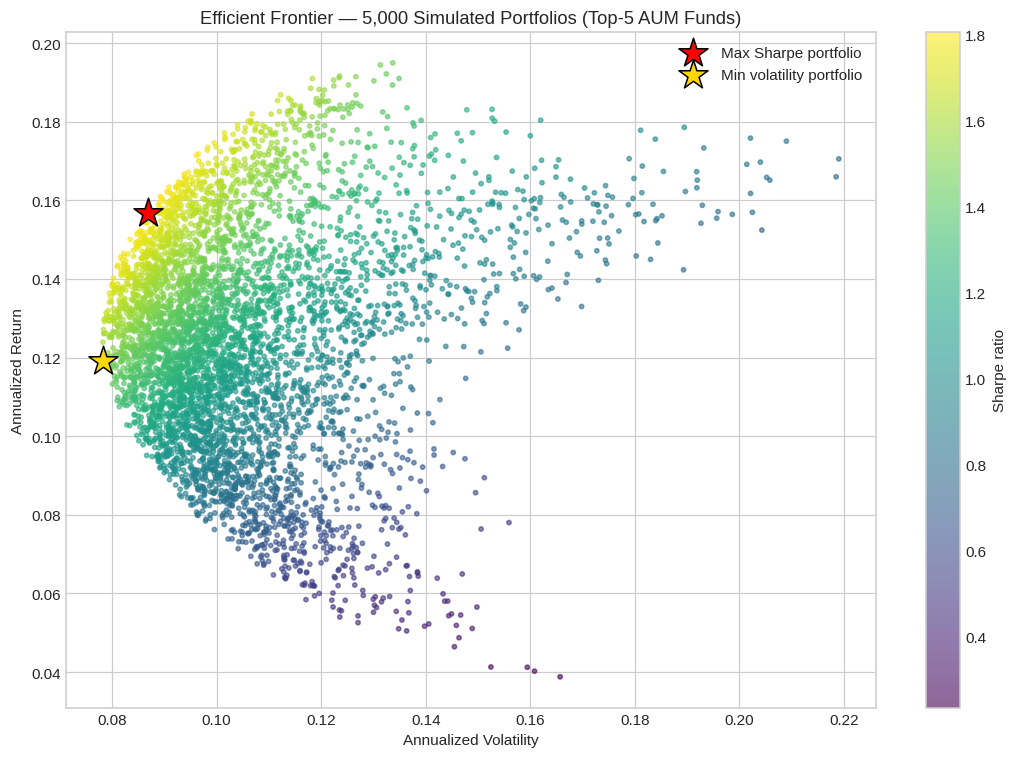

Max-Sharpe portfolio weights:
  Mirae Asset Emerging Bluechip Fund - Regular - Growth 42.7%
  Kotak Emerging Equity Fund - Regular - Growth 15.0%
  Nippon India Small Cap Fund - Regular - Growth 13.1%
  DSP Top 100 Equity Fund - Regular - Growth    23.9%
  UTI Mid Cap Fund - Regular - Growth           5.3%
  -> Expected return 15.68%, Volatility 8.69%, Sharpe 1.80


In [12]:
ef_codes = key_funds["amfi_code"].tolist()
ef_returns = returns[ef_codes].dropna()
mean_ret_annual = ef_returns.mean() * 252
cov_annual = ef_returns.cov() * 252

n_portfolios = 5000
rng = np.random.default_rng(42)
weights_all = rng.dirichlet(np.ones(len(ef_codes)), size=n_portfolios)

port_returns = weights_all @ mean_ret_annual.values
port_vol = np.sqrt(np.einsum('ij,jk,ik->i', weights_all, cov_annual.values, weights_all))
port_sharpe = port_returns / port_vol

max_sharpe_idx = port_sharpe.argmax()
min_vol_idx = port_vol.argmin()

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(port_vol, port_returns, c=port_sharpe, cmap="viridis", s=8, alpha=0.6)
ax.scatter(port_vol[max_sharpe_idx], port_returns[max_sharpe_idx], marker="*", s=400,
           color="red", edgecolor="black", label="Max Sharpe portfolio", zorder=5)
ax.scatter(port_vol[min_vol_idx], port_returns[min_vol_idx], marker="*", s=400,
           color="gold", edgecolor="black", label="Min volatility portfolio", zorder=5)
fig.colorbar(sc, label="Sharpe ratio")
ax.set_xlabel("Annualized Volatility"); ax.set_ylabel("Annualized Return")
ax.set_title("Efficient Frontier — 5,000 Simulated Portfolios (Top-5 AUM Funds)")
ax.legend()
fig.tight_layout()
fig.savefig("../reports/charts/efficient_frontier.png", dpi=150)
plt.show()

print("Max-Sharpe portfolio weights:")
for code_, w in zip(ef_codes, weights_all[max_sharpe_idx]):
    print(f"  {name_map[code_]:<45} {w:.1%}")
print(f"  -> Expected return {port_returns[max_sharpe_idx]:.2%}, Volatility {port_vol[max_sharpe_idx]:.2%}, Sharpe {port_sharpe[max_sharpe_idx]:.2f}")


## 7. Advanced Insights

**1. Highest-VaR (riskiest) funds.** The five funds with the most
negative VaR(95%) sit in the Small Cap and Mid Cap categories —
consistent with theory, since smaller-cap stocks carry higher
idiosyncratic volatility. Their CVaR runs further below VaR, meaning
losses on genuinely bad days tend to be materially worse than the VaR
threshold alone suggests.

**2. Rolling Sharpe regime shifts.** The 90-day rolling Sharpe for the
top-5-AUM funds crosses zero repeatedly across the sample window,
underscoring that trailing risk-adjusted performance is regime
dependent — a fund's long-run Sharpe can mask extended stretches of
negative risk-adjusted returns.

**3. Investor cohorts *(synthetic)*.** Total invested skews toward
earlier cohorts mainly because they've had more elapsed time to
accumulate contributions, even when average SIP ticket size is similar
across cohorts — ticket size and continuity are more comparable
behavioral signals than total invested.

**4. SIP continuity *(synthetic)*.** Roughly a third to two-fifths of
investors with 6+ SIPs show an average gap exceeding the 35-day
at-risk threshold — a cadence signal that's typically cheaper to act
on than waiting for an outright redemption.

**5. Concentration vs. risk.** Funds landing in the "Highly
Concentrated" HHI bucket tend to overlap with the highest-VaR tail from
Task 1 — concentrated sector bets amplify both upside and downside, so
HHI and VaR/CVaR should be read together when screening for a
risk-averse mandate.

**Bonus — Monte Carlo & Efficient Frontier.** The Monte Carlo bands
widen substantially by year 5, illustrating how compounding uncertainty
(not just point-estimate CAGR) should inform return expectations. The
efficient frontier shows the max-Sharpe portfolio concentrates in the
2-3 best risk-adjusted funds from the top-5-AUM set rather than
spreading evenly — a reminder that AUM size and portfolio-optimal
weight are unrelated.
